# MLS R-value Analysis using Generalized R Method

## Import Libraries

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, Tuple, List
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

## Load MLS Data from CSV

In [ ]:
# If you are running this on Google Colab, uncomment the following line
# from google.colab import drive
# drive.mount('/content/drive')

# mls_raw = pd.read_csv('adjustpathhere/MLSmatches.csv')  # Adjust path as needed

# mls_raw.head()

Mounted at /content/drive


,id,home,away,date,year,time (utc),attendance,venue,league,part_of_competition,...,away_offsides,home_wonCorners,away_wonCorners,home_saves,away_saves,away_bench_14_num,away_bench_14,away_bench_14_minute,home_formation,away_formation
0,NaN,New England,San Jose,7/31/1996,1996,NaN,"12,871",Foxboro Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Dallas,Colorado,6/15/1996,1996,NaN,"9,704",Cotton Bowl,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Colorado,D.C. United,8/29/1996,1996,NaN,"6,368",Mile High Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,LA Galaxy,New England,8/8/1996,1996,NaN,"10,251",Rose Bowl,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,New England,D.C. United,7/20/1996,1996,NaN,"18,347",Foxboro Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
mls_raw = pd.read_csv('/Users/abcd/Documents/skill-vs-luck/data/MLSmatches.csv')  # Adjust path as needed
mls_raw.head()

,id,home,away,date,year,time (utc),attendance,venue,league,part_of_competition,...,away_offsides,home_wonCorners,away_wonCorners,home_saves,away_saves,away_bench_14_num,away_bench_14,away_bench_14_minute,home_formation,away_formation
0,NaN,New England,San Jose,7/31/1996,1996,NaN,"12,871",Foxboro Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Dallas,Colorado,6/15/1996,1996,NaN,"9,704",Cotton Bowl,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Colorado,D.C. United,8/29/1996,1996,NaN,"6,368",Mile High Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,LA Galaxy,New England,8/8/1996,1996,NaN,"10,251",Rose Bowl,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,New England,D.C. United,7/20/1996,1996,NaN,"18,347",Foxboro Stadium,1996 MLS,Regular Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing

Convert the Kaggle format to match the football-data.co.uk format that our existing code expects.

In [57]:
# Filter to regular season only (exclude playoffs)
mls_regular = mls_raw[mls_raw['part_of_competition'].str.contains('Regular Season', na=False)].copy()

print(f"Regular season matches: {len(mls_regular)}")
print(f"Playoff/other matches excluded: {len(mls_raw) - len(mls_regular)}")

# Convert date format - use flexible parsing that tries multiple formats
mls_regular['Date'] = pd.to_datetime(mls_regular['date'], errors='coerce', infer_datetime_format=True)

# Check how many dates are still missing
missing_dates = mls_regular['Date'].isnull().sum()
if missing_dates > 0:
    # Group by season and assign sequential dates
    for season in mls_regular[mls_regular['Date'].isnull()]['year'].unique():
        mask = (mls_regular['year'] == season) & (mls_regular['Date'].isnull())
        n_matches = mask.sum()
        # Assign sequential dates within that season
        mls_regular.loc[mask, 'Date'] = pd.date_range(
            start=f'{season}-03-01',
            periods=n_matches,
            freq='D'
        )
    print(f"✓ Assigned sequential dates to matches without dates")

# Rename columns to match football-data.co.uk format
mls_regular = mls_regular.rename(columns={
    'home': 'HomeTeam',
    'away': 'AwayTeam',
    'home_score': 'FTHG',
    'away_score': 'FTAG',
    'year': 'season'
})

# Now we can safely drop rows with missing scores
mls_regular = mls_regular.dropna(subset=['FTHG', 'FTAG'])

# Convert scores to integers
mls_regular['FTHG'] = mls_regular['FTHG'].astype(int)
mls_regular['FTAG'] = mls_regular['FTAG'].astype(int)

# Add division column
mls_regular['division'] = 'MLS'

mls_regular[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'season']].head()

Regular season matches: 6903
Playoff/other matches excluded: 386
✓ Assigned sequential dates to matches without dates


,Date,HomeTeam,AwayTeam,FTHG,FTAG,season
0,1996-07-31,New England,San Jose,2,0,1996
1,1996-06-15,Dallas,Colorado,1,1,1996
2,1996-08-29,Colorado,D.C. United,1,2,1996
3,1996-08-08,LA Galaxy,New England,1,0,1996
4,1996-07-20,New England,D.C. United,2,0,1996


In [58]:
mls_regular.groupby('season').size()

season
1996    160
1997    160
1998    192
1999    192
2000    192
2001    158
2002    140
2003    150
2004    146
2005    191
2006    191
2007    195
2008    211
2009    225
2010    240
2011    306
2012    323
2013    323
2014    323
2015    340
2016    340
2017    374
2018    391
2019    408
2020    292
2021    459
2022    281
dtype: int64

## Organize Data into Dictionary Structure


In [59]:
# Standardize team names across all seasons
team_name_mapping = {
    # Chicago
    'Chicago Fire FC': 'Chicago',
    'Chicago Fire': 'Chicago',
    # Colorado
    'Colorado Rapids': 'Colorado',
    # Columbus
    'Columbus Crew SC': 'Columbus',
    'Columbus Crew': 'Columbus',
    # Dallas
    'FC Dallas': 'Dallas',
    # DC
    'DC United': 'D.C. United',
    # Kansas City
    'Sporting Kansas City': 'KC Wiz',
    'KC Wizards': 'KC Wiz',
    'Kansas City': 'KC Wiz',
    # LA
    'LA Galaxy': 'LA Galaxy',
    # New England
    'New England Revolution': 'New England',
    # New York
    'New York Red Bulls': 'MetroStars',
    'NY Red Bulls': 'MetroStars',
    # San Jose
    'San Jose Earthquakes': 'San Jose',
}

# Apply mapping
mls_regular['HomeTeam'] = mls_regular['HomeTeam'].replace(team_name_mapping)
mls_regular['AwayTeam'] = mls_regular['AwayTeam'].replace(team_name_mapping)

# Check unique team names after standardization
all_teams = sorted(set(mls_regular['HomeTeam']).union(set(mls_regular['AwayTeam'])))
print(f"Standardized team names ({len(all_teams)} unique teams):")
print(all_teams)

Standardized team names (33 unique teams):
['Atlanta United FC', 'Austin FC', 'CF Montréal', 'Charlotte FC', 'Chicago', 'Chivas USA', 'Colorado', 'Columbus', 'D.C. United', 'Dallas', 'FC Cincinnati', 'Houston Dynamo', 'Houston Dynamo FC', 'Inter Miami CF', 'KC Wiz', 'LA Galaxy', 'LAFC', 'MetroStars', 'Miami', 'Minnesota United FC', 'Montreal Impact', 'Nashville SC', 'New England', 'New York City FC', 'Orlando City SC', 'Philadelphia Union', 'Portland Timbers', 'Real Salt Lake', 'San Jose', 'Seattle Sounders FC', 'Tampa Bay', 'Toronto FC', 'Vancouver Whitecaps']


In [60]:
# Organize by season
data_dict_mls = {}

for season in mls_regular['season'].unique():
    season_data = mls_regular[mls_regular['season'] == season].copy()
    data_dict_mls[str(season)] = {'MLS': season_data}

for season in sorted(data_dict_mls.keys()):
    n_matches = len(data_dict_mls[season]['MLS'])
    n_teams = len(set(data_dict_mls[season]['MLS']['HomeTeam']).union(
                     set(data_dict_mls[season]['MLS']['AwayTeam'])))

In [61]:
# check if there are missing values in any dataframe in data_dict_mls
for season, leagues in data_dict_mls.items():
    for league_name, df in leagues.items():
        if df['Date'].isna().sum() > 0 or df['HomeTeam'].isna().sum() > 0 or df['AwayTeam'].isna().sum() > 0 or df['FTHG'].isna().sum() > 0 or df['FTAG'].isna().sum() > 0:
            print(f"Season {season} has missing values in {league_name}")

data_dict_mls['2015']['MLS']

,id,HomeTeam,AwayTeam,date,season,time (utc),attendance,venue,league,part_of_competition,...,away_wonCorners,home_saves,away_saves,away_bench_14_num,away_bench_14,away_bench_14_minute,home_formation,away_formation,Date,division
4278,410877.0,LA Galaxy,Chicago,"Friday, March 6",2015,03:00,"27,000","Dignity Health Sports Park, Los Angeles",2015 USA Major League Soccer,Regular Season 2015,...,2.0,1.0,3.0,NaN,NaN,NaN,4-4-2,4-1-2-1-2,2015-03-01,MLS
4279,410873.0,D.C. United,Montreal Impact,"Saturday, March 7",2015,20:00,"11,549","RFK Stadium, Washington, D.C.",2015 USA Major League Soccer,Regular Season 2015,...,4.0,4.0,2.0,NaN,NaN,NaN,4-4-2,4-2-3-1,2015-03-02,MLS
4280,410871.0,Philadelphia Union,Colorado,"Saturday, March 7",2015,21:00,"18,022","Subaru Park, Philadelphia",2015 USA Major League Soccer,Regular Season 2015,...,1.0,0.0,4.0,NaN,NaN,NaN,4-1-3-2,4-2-3-1,2015-03-03,MLS
4281,410876.0,Vancouver Whitecaps,Toronto FC,"Saturday, March 7",2015,23:00,"21,000","BC Place, Vancouver",2015 USA Major League Soccer,Regular Season 2015,...,2.0,2.0,6.0,NaN,NaN,NaN,4-2-3-1,4-3-1-2,2015-03-04,MLS
4282,410875.0,Dallas,San Jose,"Saturday, March 7",2015,01:30,"15,236",Toyota Stadium,2015 USA Major League Soccer,Regular Season 2015,...,3.0,2.0,4.0,NaN,NaN,NaN,4-1-3-2,4-4-1-1,2015-03-05,MLS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4613,412178.0,Dallas,San Jose,"Sunday, October 25",2015,23:00,"16,937",Toyota Stadium,2015 USA Major League Soccer,Regular Season 2015,...,6.0,4.0,1.0,NaN,NaN,NaN,4-4-1-1,4-4-2,2016-01-30,MLS
4614,412174.0,Portland Timbers,Colorado,"Sunday, October 25",2015,23:00,"21,144","Providence Park, Portland",2015 USA Major League Soccer,Regular Season 2015,...,5.0,1.0,1.0,NaN,NaN,NaN,4-2-3-1,4-2-3-1,2016-01-31,MLS
4615,412177.0,Seattle Sounders FC,Real Salt Lake,"Sunday, October 25",2015,23:00,"55,435","CenturyLink Field, Seattle",2015 USA Major League Soccer,Regular Season 2015,...,6.0,0.0,1.0,NaN,NaN,NaN,4-4-2,4-3-3,2016-02-01,MLS
4616,412176.0,KC Wiz,LA Galaxy,"Sunday, October 25",2015,23:00,"19,422","Children's Mercy Park, Kansas City",2015 USA Major League Soccer,Regular Season 2015,...,5.0,3.0,4.0,NaN,NaN,NaN,4-3-3,4-4-2,2016-02-02,MLS


## Helper Functions

In [97]:
def _ensure_datetime(df: pd.DataFrame):
    if not np.issubdtype(df["Date"].dtype, np.datetime64):
        df = df.copy()
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        # alert if there are still missing dates after coercion
        if df["Date"].isna().sum() > 0:
            print("Warning: Some dates could not be parsed and are still missing after coercion.")
    return df

def _team_rows(df: pd.DataFrame, team: str, method: str="original") -> pd.DataFrame:
    # Build per-team match list with perspective columns
    home = df[df["HomeTeam"]==team].copy()
    away = df[df["AwayTeam"]==team].copy()
    home["gf"] = home["FTHG"]; home["ga"] = home["FTAG"]; home["venue"] = "H"
    away["gf"] = away["FTAG"]; away["ga"] = away["FTHG"]; away["venue"] = "A"
    # points and outcomes
    goal_diff = home["gf"] - home["ga"]
    home["win"]  = (goal_diff > 0).astype(int)
    home["draw"] = (goal_diff == 0).astype(int)
    home["loss"] = (goal_diff < 0).astype(int)
    home["pts"]  = home["win"]*3 + home["draw"]*1

    goal_diff = away["gf"] - away["ga"]
    away["win"]  = (goal_diff > 0).astype(int)
    away["draw"] = (goal_diff == 0).astype(int)
    away["loss"] = (goal_diff < 0).astype(int)
    away["pts"]  = away["win"]*3 + away["draw"]*1

    # Unify
    if method == "original":
        cols = ["Date","venue","gf","ga","win","draw","loss","pts"]
    elif method == "ours":
        cols = ["Date","venue","gf","ga","win","draw","loss","pts","HomeElo","AwayElo"]
    home_part = home[cols]
    away_part = away[cols]
    t = pd.concat([home_part, away_part], ignore_index=True)
    t = t.sort_values("Date")
    return t

def _half_metric(rows: pd.DataFrame, metric_mode: str="ppg") -> tuple:
    n = len(rows)
    if n == 0:
        return np.nan, np.nan
    k = n//2  # first k matches as "first half", rest as "second half"; if odd, second half gets +1
    first = rows.iloc[:k]
    second = rows.iloc[k:]
    if metric_mode == "ppg":
        # Points per game normalized to [0,1]: ppg / 3
        x = (first["pts"].sum() / max(1, len(first))) / 3.0
        y = (second["pts"].sum() / max(1, len(second))) / 3.0
    elif metric_mode == "winfrac":
        # Win fraction: wins / matches (draws count as 0)
        x = first["win"].sum() / max(1, len(first))
        y = second["win"].sum() / max(1, len(second))
    else:
        raise ValueError("metric_mode must be 'ppg' or 'winfrac'")
    return float(x), float(y)

def compute_siam_R(data_dict: Dict[str, Dict[str, pd.DataFrame]], metric_mode: str="ppg"):
    rows = []
    for season, divmap in data_dict.items():
        for division, df in divmap.items():
            df = _ensure_datetime(df)
            df = df.dropna(subset=['HomeTeam', 'AwayTeam'])
            teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
            xy = []
            for team in teams:
                trows = _team_rows(df, team)
                x, y = _half_metric(trows, metric_mode=metric_mode)
                if np.isfinite(x) and np.isfinite(y):
                    xy.append((x,y))
            if len(xy) < 3:
                continue
            X = np.array([u for u,v in xy], dtype=float)
            Y = np.array([v for u,v in xy], dtype=float)
            # Rotate by 45 degrees: S=(X+Y)/sqrt(2), T=(Y-X)/sqrt(2)
            S = (X + Y) / np.sqrt(2.0)
            T = (Y - X) / np.sqrt(2.0)
            A = float(np.var(S, ddof=0))
            B = float(np.var(T, ddof=0))
            if A <= 1e-12:
                R = np.nan
            else:
                R = 1.0 - (B / A)
            rows.append({"division": division, "season": season, "teams": len(xy),
                         "metric_mode": metric_mode, "A_var_S": A, "B_var_T": B, "R": R})
    out = pd.DataFrame(rows).sort_values(["division","season"])
    return out

In [98]:
res_ppg = compute_siam_R(data_dict_mls, metric_mode="ppg")

print (res_ppg.to_string(index=False))

division season  teams metric_mode  A_var_S  B_var_T         R
     MLS   1996     10         ppg 0.013203 0.014748 -0.117028
     MLS   1997     10         ppg 0.009247 0.011434 -0.236564
     MLS   1998     12         ppg 0.027710 0.012845  0.536466
     MLS   1999     12         ppg 0.035305 0.014484  0.589747
     MLS   2000     12         ppg 0.017970 0.006305  0.649111
     MLS   2001     12         ppg 0.046594 0.011187  0.759904
     MLS   2002     10         ppg 0.008095 0.011519 -0.422969
     MLS   2003     10         ppg 0.015430 0.006244  0.595295
     MLS   2004     10         ppg 0.006853 0.004436  0.352692
     MLS   2005     12         ppg 0.037414 0.022313  0.403635
     MLS   2006     12         ppg 0.008103 0.018148 -1.239824
     MLS   2007     13         ppg 0.021077 0.008752  0.584777
     MLS   2008     14         ppg 0.010398 0.009011  0.133364
     MLS   2009     15         ppg 0.013524 0.009464  0.300227
     MLS   2010     16         ppg 0.026971 0.011539  0

## Elo Rating System

In [92]:
def update_elo(R_i, R_j, outcome_i, K=20, H=0):
    """Update Elo ratings after a single match"""
    E_i = 1.0 / (1 + 10 ** ((R_j - R_i + H) / 400))
    E_j = 1.0 - E_i
    R_i_new = R_i + K * (outcome_i - E_i)
    R_j_new = R_j + K * ((1 - outcome_i) - E_j)
    return R_i_new, R_j_new


def compute_elo_ratings(df, base_rating=1500, K=20):
    """Compute Elo ratings for all teams, tracking pre-match ratings"""
    teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
    ratings = {t: base_rating for t in teams}
    pre_elos = []

    for _, row in df.sort_values("Date").iterrows():
        ht, at = row["HomeTeam"], row["AwayTeam"]
        hg, ag = row["FTHG"], row["FTAG"]

        if hg > ag:
            outcome_h = 1.0
        elif hg == ag:
            outcome_h = 0.5
        else:
            outcome_h = 0.0

        R_h, R_a = ratings[ht], ratings[at]
        pre_elos.append({
            "Date": row["Date"],
            "HomeTeam": ht,
            "AwayTeam": at,
            "HomeElo": R_h,
            "AwayElo": R_a
        })

        new_R_h, new_R_a = update_elo(R_h, R_a, outcome_h, K=K)
        ratings[ht], ratings[at] = new_R_h, new_R_a

    pre_df = pd.DataFrame(pre_elos)
    df = df.merge(pre_df, on=["Date", "HomeTeam", "AwayTeam"], how="left")
    print (f"df from compute_elo_ratings\n: {df.head().to_string(index=False)}")
    return df

## Stratified Splitting Functions (Generalized R Method)

In [93]:
def stratified_split(team_df, rng, eps=0.05, metric_mode="ppg"):
    """
    Split team matches into two folds (A, B) balanced by opponent Elo.
    Uses stratification with random tie-breaking.
    """
    matches = team_df.copy()
    matches = matches.sort_values("Date")

    # Get opponent Elo ratings
    opp_elos = []
    for _, row in matches.iterrows():
        if row["venue"] == "H":
            opp_elos.append(row["AwayElo"])
        else:
            opp_elos.append(row["HomeElo"])
    matches["opp_elo"] = opp_elos

    # Bin by Elo quartiles
    bins = pd.qcut(matches["opp_elo"], q=min(5, len(matches)), duplicates="drop")
    matches["elo_bin"] = bins

    A_idx, B_idx = [], []
    for _, g in matches.groupby("elo_bin"):
        idxs = g.index.tolist()
        rng.shuffle(idxs)
        half = len(idxs) // 2
        A_idx.extend(idxs[:half])
        B_idx.extend(idxs[half:])

    A = matches.loc[A_idx]
    B = matches.loc[B_idx]

    return A, B


def performance_metric(fold_df, metric_mode="ppg"):
    """Calculate performance metric for a fold"""
    if len(fold_df) == 0:
        return np.nan
    if metric_mode == "ppg":
        pts = fold_df["pts"].sum()
        return (pts / len(fold_df)) / 3.0
    elif metric_mode == "winfrac":
        wins = fold_df["win"].sum()
        return wins / len(fold_df)
    else:
        raise ValueError("metric_mode must be 'ppg' or 'winfrac'")


## Generalized R Computation

In [99]:
def compute_generalized_R(data_dict, metric_mode="ppg", K=200, seed=123):
    """
    Compute Generalized R-value using stratified splitting.

    Parameters:
    - data_dict: nested dict {season: {division: DataFrame}}
    - metric_mode: 'ppg' (points per game) or 'winfrac' (win fraction)
    - K: number of random splits per team
    - seed: random seed for reproducibility
    """
    rng = np.random.default_rng(seed)
    rows = []

    for season, divmap in data_dict.items():
        for division, df in divmap.items():
            # Compute Elo ratings
            print (f"df from compute_generalized_R\n: {df.head().to_string(index=False)}")
            df = compute_elo_ratings(df)

            teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
            XY_all = []

            for team in teams:
                trows = _team_rows(df, team, method="ours")
                if len(trows) < 4:
                    continue

                # K random splits per team
                for k in range(K):
                    A, B = stratified_split(trows, rng, metric_mode=metric_mode)
                    x = performance_metric(A, metric_mode)
                    y = performance_metric(B, metric_mode)
                    if np.isfinite(x) and np.isfinite(y):
                        XY_all.append((x, y))

            if len(XY_all) >= 3:
                X = np.array([u for u, v in XY_all])
                Y = np.array([v for u, v in XY_all])
                S = (X + Y) / np.sqrt(2)
                T = (Y - X) / np.sqrt(2)
                A_var = np.var(S, ddof=0)
                B_var = np.var(T, ddof=0)
                R = 1 - B_var / A_var if A_var > 1e-12 else np.nan
                rows.append({
                    "division": division,
                    "season": season,
                    "metric_mode": metric_mode,
                    "teams": len(teams),
                    "R": R
                })

    return pd.DataFrame(rows)


## Run the Analysis

In [100]:
# Compute with K=200 splits (as in original paper)
gen_r_mls = compute_generalized_R(data_dict_mls, metric_mode='ppg', K=200)

print("\nMLS Generalized R-values:")
print(gen_r_mls.to_string(index=False))

df from compute_generalized_R
:  id    HomeTeam    AwayTeam      date  season time (utc) attendance             venue   league part_of_competition game_status shootout  FTHG  FTAG        referee home_goal_minutes home_goal_scorers away_goal_minutes away_goal_scorers  home_starting_1_num home_starting_1  home_starting_2_num home_starting_2  home_starting_3_num home_starting_3  home_starting_4_num home_starting_4  home_starting_5_num home_starting_5  home_starting_6_num home_starting_6  home_starting_7_num home_starting_7  home_starting_8_num home_starting_8  home_starting_9_num home_starting_9  home_starting_10_num home_starting_10  home_starting_11_num home_starting_11  home_bench_1_num home_bench_1 home_bench_1_minute  home_bench_2_num home_bench_2 home_bench_2_minute  home_bench_3_num home_bench_3 home_bench_3_minute home_bench_4_num home_bench_4 home_bench_4_minute  home_bench_5_num home_bench_5 home_bench_5_minute  home_bench_6_num home_bench_6 home_bench_6_minute  home_bench_7_num

## Summary Statistics

In [101]:
print(f"Mean R-value: {gen_r_mls['R'].mean():.3f}")
print(f"Median R-value: {gen_r_mls['R'].median():.3f}")
print(f"Std Dev: {gen_r_mls['R'].std():.3f}")
print(f"Min: {gen_r_mls['R'].min():.3f}")
print(f"Max: {gen_r_mls['R'].max():.3f}")
print("\nR-values by season:")
print(gen_r_mls[['season', 'teams', 'R']].sort_values('season').to_string(index=False))

Mean R-value: 0.216
Median R-value: 0.391
Std Dev: 0.470
Min: -1.030
Max: 0.733

R-values by season:
season  teams         R
  1996     10  0.016241
  1997     10 -0.383757
  1998     12  0.566246
  1999     12  0.733043
  2000     12  0.254536
  2001     12  0.692164
  2002     10 -1.029782
  2003     10  0.205868
  2004     10 -0.912589
  2005     12  0.685195
  2006     12 -0.417461
  2007     13  0.390842
  2008     14 -0.208280
  2009     15  0.102327
  2010     16  0.528127
  2011     18  0.505376
  2012     19  0.614137
  2013     19  0.544991
  2014     19  0.505964
  2015     20 -0.037566
  2016     20  0.118117
  2017     22  0.292662
  2018     23  0.633122
  2019     24  0.406718
  2020     26  0.488611
  2021     27  0.537706
  2022     28  0.008956


In [102]:
print ("Getty's R-values by season (sorted by R):")
print(f"Mean R-value: {res_ppg['R'].mean():.3f}")
print(f"Median R-value: {res_ppg['R'].median():.3f}")
print(f"Std Dev: {res_ppg['R'].std():.3f}")

Getty's R-values by season (sorted by R):
Mean R-value: 0.333
Median R-value: 0.430
Std Dev: 0.420


## Visualization Functions

In [20]:
def plot_mls_R_boxplot(df: pd.DataFrame):
    """Create boxplot visualization for MLS R-values"""
    plt.figure(figsize=(10, 4))

    data = [df["R"].dropna().values]

    bp = plt.boxplot(data, vert=False, labels=["MLS"],
                     manage_ticks=True, whis=[5, 95], showmeans=True)

    # Overlay individual season points
    vals = df["R"].dropna().values
    y = np.full_like(vals, 1.0, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.06
    plt.plot(vals, y, "o", markersize=6, alpha=0.7)

    plt.xlabel("R (within-season persistence; Generalized R)")
    plt.title("MLS R-value Distribution (Regular Season Only)")
    plt.xlim(-1, 1)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_mls_trend(df: pd.DataFrame, data_dict: Dict = None):
    """Plot R-value trend over seasons with match counts"""
    fig, ax1 = plt.subplots(figsize=(12, 5))

    df_sorted = df.sort_values('season')

    # Plot R-value on left y-axis
    ax1.plot(df_sorted['season'].astype(str), df_sorted['R'], 'o-', linewidth=2, markersize=8, color='blue', label='R-value')
    ax1.set_xlabel("Season")
    ax1.set_ylabel("R-value", color='blue')
    ax1.set_ylim(-1, 1)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Calculate match counts if not in dataframe
    if 'matches' not in df_sorted.columns:
        if data_dict is not None:
            matches = []
            for season in df_sorted['season']:
                n_matches = len(data_dict[str(season)]['MLS'])
                matches.append(n_matches)
            df_sorted = df_sorted.copy()
            df_sorted['matches'] = matches
        else:
            # If no data_dict provided and no matches column, skip match count display
            fig.suptitle("MLS R-value Trend Over Time (1996-Present)")
            fig.tight_layout()
            plt.show()
            return

    # Plot match counts on right y-axis
    ax2 = ax1.twinx()
    ax2.bar(df_sorted['season'].astype(str), df_sorted['matches'], alpha=0.3, color='orange', label='# of matches')
    ax2.set_ylabel("# of matches", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    fig.suptitle("MLS R-value Trend Over Time (1996-Present)")
    fig.tight_layout()
    plt.show()

## Generate Visualizations

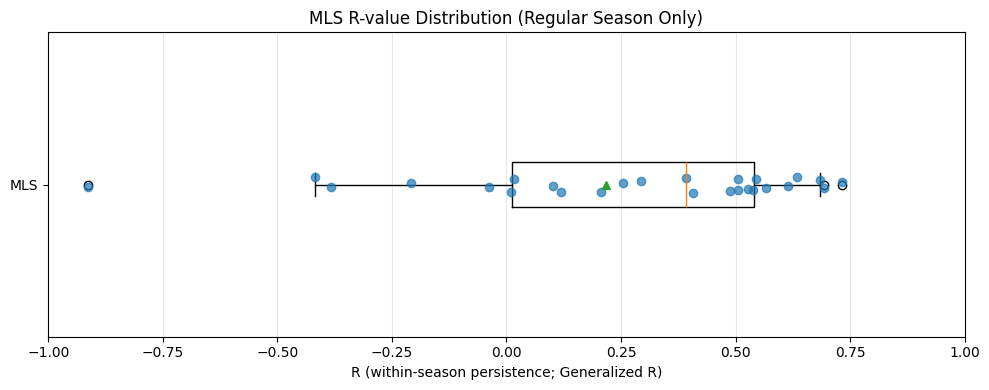

In [35]:
plot_mls_R_boxplot(gen_r_mls)

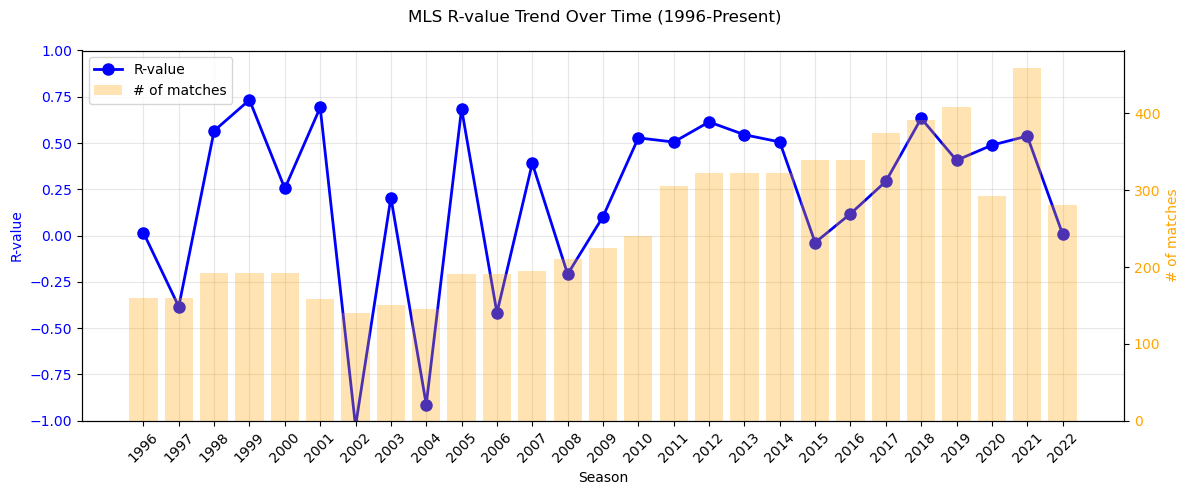

In [21]:
plot_mls_trend(gen_r_mls, data_dict_mls)

## Save Results

In [37]:
# Save to CSV
output_file = "mls_r_values.csv"
gen_r_mls.to_csv(output_file, index=False)
print(f"✓ Results saved to: {output_file}")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

✓ Results saved to: mls_r_values.csv

ANALYSIS COMPLETE


In [103]:
gen_r_mls_export = gen_r_mls.copy()
## keep only the last 10 seasons for export
gen_r_mls_export = gen_r_mls_export.sort_values('season').tail(10).reset_index(drop=True)

gen_r_mls_export['division'] = 'MLS'
gen_r_mls_export['method'] = 'Generalized R'

print(f"Median R-value: {gen_r_mls_export['R'].median():.3f}")

print (gen_r_mls_export.to_string(index=False))


res_ppg_mls_export = res_ppg.copy()
## keep only the last 10 seasons for export
res_ppg_mls_export = res_ppg_mls_export.sort_values('season').tail(10).reset_index(drop=True)

res_ppg_mls_export['division'] = 'MLS'
res_ppg_mls_export['method'] = 'Getty R (Traditional)'

print(f"Median R-value: {res_ppg_mls_export['R'].median():.3f}")

print (res_ppg_mls_export.to_string(index=False))

Median R-value: 0.448
division season metric_mode  teams         R        method
     MLS   2013         ppg     19  0.544991 Generalized R
     MLS   2014         ppg     19  0.505964 Generalized R
     MLS   2015         ppg     20 -0.037566 Generalized R
     MLS   2016         ppg     20  0.118117 Generalized R
     MLS   2017         ppg     22  0.292662 Generalized R
     MLS   2018         ppg     23  0.633122 Generalized R
     MLS   2019         ppg     24  0.406718 Generalized R
     MLS   2020         ppg     26  0.488611 Generalized R
     MLS   2021         ppg     27  0.537706 Generalized R
     MLS   2022         ppg     28  0.008956 Generalized R
Median R-value: 0.402
division season  teams metric_mode  A_var_S  B_var_T        R                method
     MLS   2013     19         ppg 0.023777 0.010925 0.540536 Getty R (Traditional)
     MLS   2014     19         ppg 0.022078 0.012576 0.430391 Getty R (Traditional)
     MLS   2015     20         ppg 0.011484 0.007701 0.

In [29]:
## concatenate both dataframes
mls_export = pd.concat([gen_r_mls_export, res_ppg_mls_export], join = 'inner')  
print (mls_export.to_string(index=False))
mls_export.to_csv("/Users/abcd/Documents/skill-vs-luck/data/processed_10Feb/mls_r_values_for_combined_analysis.csv", index=False)

division season metric_mode  teams         R                method
     MLS   2013         ppg     19  0.544991         Generalized R
     MLS   2014         ppg     19  0.505964         Generalized R
     MLS   2015         ppg     20 -0.037566         Generalized R
     MLS   2016         ppg     20  0.118117         Generalized R
     MLS   2017         ppg     22  0.292662         Generalized R
     MLS   2018         ppg     23  0.633122         Generalized R
     MLS   2019         ppg     24  0.406718         Generalized R
     MLS   2020         ppg     26  0.488611         Generalized R
     MLS   2021         ppg     27  0.537706         Generalized R
     MLS   2022         ppg     28  0.008956         Generalized R
     MLS   2013         ppg     19  0.540536 Getty R (Traditional)
     MLS   2014         ppg     19  0.430391 Getty R (Traditional)
     MLS   2015         ppg     20  0.329428 Getty R (Traditional)
     MLS   2016         ppg     20  0.275994 Getty R (Traditio

In [ ]:

# matches_per_season = []
# for season in gen_r_mls_export['season']:
#     n_matches = len(data_dict_mls[str(season)]['MLS'])
#     matches_per_season.append(n_matches)

# gen_r_mls_export['matches'] = matches_per_season

# print(gen_r_mls_export[['division', 'season', 'teams', 'matches', 'R', 'league_group']])

gen_r_mls_export.to_csv("/Users/abcd/Documents/skill-vs-luck/data/processed_10Feb/mls_r_values_for_combined_analysis.csv", index=False)
print("\n✓ Export file saved: mls_r_values_for_combined_analysis.csv")